# [RSNA 2023 Abdominal Trauma Detection](https://www.kaggle.com/competitions/rsna-2023-abdominal-trauma-detection)

> Detect and classify traumatic abdominal injuries

![](https://www.kaggle.com/competitions/52254/images/header)

In [58]:
import warnings
warnings.filterwarnings('ignore')

In [59]:
!pip install torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 5.0 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manylinux1_x86_64.whl (166.0 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-many

In [60]:
!pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16429 sha256=2b9606885b8efaa855eaffe983edcdf392d9e1686b637559ce6d5f79798268d6
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
Successfully built efficientnet_pytorch


In [61]:
!pip install onnx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 52.4 MB/s eta 0:00:00


# Evaluation Function

In [62]:
from tabulate import tabulate
from torch import nn,sigmoid,softmax,cuda,inference_mode
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
from torchmetrics.classification import BinaryAccuracy, MulticlassAccuracy, BinaryAUROC, MulticlassAUROC, BinaryAveragePrecision, MulticlassAveragePrecision, BinaryF1Score, MulticlassF1Score, BinaryCalibrationError, MulticlassCalibrationError
# Define a function to print the DataFrame after each epoch
def print_model_train_results(results):
    df_results = pd.DataFrame(results)
    # Set 'Type' as the index
    df_results.set_index("Results", inplace=True)
    print(tabulate(df_results, headers='keys', tablefmt='fancy_grid'),"\n")

def model_evaluation(model: nn.Module,
                    dataloader: DataLoader,
                    criterion_bowel: nn.Module,
                    criterion_extra: nn.Module,
                    criterion_kidney: nn.Module,
                    criterion_liver: nn.Module,
                    criterion_spleen: nn.Module):
    """
    Perform a model evaluation on testing data.

    Parameters:
        model (nn.Module): The neural network model.
        dataloader (torch.utils.data.DataLoader): DataLoader for the testing dataset.
        criterion_bowel (nn.Module): Loss function for bowel task.
        criterion_extra (nn.Module): Loss function for extra task.
        criterion_liver (nn.Module): Loss function for liver task.
        criterion_kidney (nn.Module): Loss function for kidney task.
        criterion_spleen (nn.Module): Loss function for spleen task.

    Returns:
        No print model evaluation on testing data
    """
    device = "cuda" if cuda.is_available() else "cpu"

    # Getting accuracy
    binary_acc = BinaryAccuracy().to(device)
    multi_acc = MulticlassAccuracy(num_classes=3).to(device)
    # Getting f1score
    binary_f1 = BinaryF1Score().to(device)
    multi_f1 = MulticlassF1Score(num_classes=3).to(device)
    # Getting Calibration Error
    binary_ce = BinaryCalibrationError().to(device)
    multi_ce = MulticlassCalibrationError(num_classes=3).to(device)

    # Create testing metrics variables
    test_loss, test_acc_bowel, test_acc_extra, test_acc_kidney, test_acc_liver, test_acc_spleen = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    test_f1_bowel, test_f1_extra, test_f1_liver, test_f1_kidney, test_f1_spleen = 0.0, 0.0, 0.0, 0.0, 0.0
    test_ce_bowel, test_ce_extra, test_ce_liver, test_ce_kidney, test_ce_spleen = 0.0, 0.0, 0.0, 0.0, 0.0

    # Set model to evaluation mode
    model.eval()

    # Iterate over testing dataloader
    with inference_mode():
        for batch_idx, (X, y_bowel, y_extra, y_kidney, y_liver, y_spleen) in tqdm(enumerate(dataloader), desc="Testing", total=len(dataloader)):
            # Move data to appropriate device
            X, y_bowel, y_extra, y_kidney,y_liver, y_spleen = X.to(device), y_bowel.to(device), y_extra.to(device), y_kidney.to(device), y_liver.to(device), y_spleen.to(device)

            # Forward pass
            bowel_out, extra_out, kidney_out,liver_out, spleen_out = model(X)

            y_bowel = y_bowel.view(-1,1)
            y_extra = y_extra.view(-1,1)
            # Calculate loss
            loss_bowel = criterion_bowel(bowel_out, y_bowel)
            loss_extra = criterion_extra(extra_out, y_extra)
            loss_kidney = criterion_kidney(kidney_out, y_kidney)
            loss_liver = criterion_liver(liver_out, y_liver)
            loss_spleen = criterion_spleen(spleen_out, y_spleen)

            # Accumulate loss
            test_loss += (loss_bowel.item() + loss_extra.item() + loss_kidney.item() + loss_liver.item() + loss_spleen.item())
            # Compute accuracy for each task
            test_acc_bowel += binary_acc(sigmoid(bowel_out), y_bowel).item()
            test_acc_extra += binary_acc(sigmoid(extra_out), y_extra).item()
            test_acc_kidney += multi_acc(softmax(kidney_out,dim=1).argmax(dim=1), y_kidney.argmax(dim=1)).item()
            test_acc_liver += multi_acc(softmax(liver_out,dim=1).argmax(dim=1), y_liver.argmax(dim=1)).item()
            test_acc_spleen += multi_acc(softmax(spleen_out,dim=1).argmax(dim=1), y_spleen.argmax(dim=1)).item()

            # Compute F1 score for each task
            test_f1_bowel += binary_f1(sigmoid(bowel_out), y_bowel).item()
            test_f1_extra += binary_f1(sigmoid(extra_out), y_extra).item()
            test_f1_kidney += multi_f1(softmax(kidney_out,dim=1).argmax(dim=1), y_kidney.argmax(dim=1)).item()
            test_f1_liver += multi_f1(softmax(liver_out,dim=1).argmax(dim=1), y_liver.argmax(dim=1)).item()
            test_f1_spleen += multi_f1(softmax(spleen_out,dim=1).argmax(dim=1), y_spleen.argmax(dim=1)).item()

            # Compute Calibration Error for each task
            test_ce_bowel += binary_ce(bowel_out, y_bowel).item()
            test_ce_extra += binary_ce(extra_out, y_extra).item()
            test_ce_kidney += multi_ce(kidney_out, y_kidney.argmax(dim=1)).item()
            test_ce_liver += multi_ce(liver_out, y_liver.argmax(dim=1)).item()
            test_ce_spleen += multi_ce(spleen_out, y_spleen.argmax(dim=1)).item()

    # Compute average loss, accuracy, and F1 score
    num_batches = len(dataloader)
    test_loss /= (num_batches)
    # Compute average acc
    test_acc_bowel /= num_batches
    test_acc_extra /= num_batches
    test_acc_kidney /= num_batches
    test_acc_liver /= num_batches
    test_acc_spleen /= num_batches

    # Compute average f1
    test_f1_bowel /= num_batches
    test_f1_extra /= num_batches
    test_f1_kidney /= num_batches
    test_f1_liver /= num_batches
    test_f1_spleen /= num_batches

    # Compute average ce
    test_ce_bowel /= num_batches
    test_ce_extra /= num_batches
    test_ce_kidney /= num_batches
    test_ce_liver /= num_batches
    test_ce_spleen /= num_batches

    print(f"Test loss is: {test_loss:.4f}")
    print_model_train_results({
    "Results":["Accuracy","F1_Score","Calibration_Error"],
    "bowel": [test_acc_bowel, test_f1_bowel, test_ce_bowel],
    "extravation": [test_acc_extra, test_f1_extra, test_ce_extra],
    "kidney": [test_acc_kidney, test_f1_kidney, test_ce_kidney],
    "liver": [test_acc_liver, test_f1_liver, test_ce_liver],
    "spleen": [test_acc_spleen, test_f1_spleen, test_ce_spleen]
    })

In [63]:
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from torchmetrics.classification import BinaryROC, MulticlassROC

def plot_roc_curves(model: nn.Module, dataloader: DataLoader):
    # Create instances of the ROC metric
    binary_roc_bowel = BinaryROC().to(device)
    binary_roc_extra = BinaryROC().to(device)
    multi_roc_kidney = MulticlassROC(num_classes=3).to(device)
    multi_roc_liver = MulticlassROC(num_classes=3).to(device)
    multi_roc_spleen = MulticlassROC(num_classes=3).to(device)

    # Evaluation loop
    model.eval()
    with torch.inference_mode():
        for batch_idx, (X, y_bowel, y_extra, y_kidney, y_liver, y_spleen) in enumerate(dataloader):
            # Move data to appropriate device
            X, y_bowel, y_extra, y_kidney, y_liver, y_spleen = X.to(device), y_bowel.to(device), y_extra.to(device), y_kidney.to(device), y_liver.to(device), y_spleen.to(device)
            # Forward pass
            bowel_out, extra_out, kidney_out, liver_out, spleen_out = model(X)
            # Update ROC metrics
            binary_roc_bowel(bowel_out, y_bowel.long())
            binary_roc_extra(extra_out, y_extra.long())
            multi_roc_kidney(kidney_out, y_kidney.argmax(dim=1))
            multi_roc_liver(liver_out, y_liver.argmax(dim=1))
            multi_roc_spleen(spleen_out, y_spleen.argmax(dim=1))

    # Plot ROC curves
    fig0, ax0 = plt.subplots(2, 3, figsize=(15, 10))
    ax0 = ax0.ravel()

    # Plot ROC curve for Bowel (assuming binary classification)
    fig1, ax1 = binary_roc_bowel.plot(score=True, ax=ax0[0])
    ax1.set_title('Bowel ROC Curve')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Classifier')
    ax1.legend()

    # Plot ROC curve for Extravasation (assuming binary classification)
    fig2, ax2 = binary_roc_extra.plot(score=True, ax=ax0[1])
    ax2.set_title('Extravasation ROC Curve')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Classifier')
    ax2.legend()

    # Plot ROC curves for other organs (assuming multiclass classification)
    fig3, ax3 = multi_roc_kidney.plot(score=True, ax=ax0[2])
    ax3.set_title('Kidney ROC Curve')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Classifier')

    # Plot ROC curves for other organs (assuming multiclass classification)
    fig4, ax4 = multi_roc_liver.plot(score=True, ax=ax0[3])
    ax4.set_title('Liver ROC Curve')
    ax4.set_xlabel('False Positive Rate')
    ax4.set_ylabel('True Positive Rate')
    ax4.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Classifier')

    # Plot ROC curves for other organs (assuming multiclass classification)
    fig5, ax5 = multi_roc_spleen.plot(score=True, ax=ax0[4])
    ax5.set_title('Spleen ROC Curve')
    ax5.set_xlabel('False Positive Rate')
    ax5.set_ylabel('True Positive Rate')
    ax5.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Classifier')

    # Add legend with custom colors
    custom_lines = [plt.Line2D([0], [0], color='dodgerblue', lw=4),
                    plt.Line2D([0], [0], color='mediumseagreen', lw=4),
                    plt.Line2D([0], [0], color='Orange', lw=4)]
    fig0.legend(custom_lines, ['Healthy AUC', 'Low AUC', 'High AUC'], loc='lower right', bbox_to_anchor=(0.3,0.3, 0.5, 0.5))
    fig0.delaxes(ax0[5])
    plt.tight_layout()  # Adjust spacing to avoid overlapping elements
    plt.show()

# Infernce Notebook
🔑 **Note**: This notebook consist of inference of all model that we have created so far as follow:
* `ATD_EfficientNetB1_Model.`
* `ATD_EfficientNetB1_CutMixUp_Model.`
* `ATD_ResNet50_Model.`
* `ATD_ResNet50_CutMixUp_Model.`

In [64]:
# Setting Up Device
import torch
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## 2. Loding Test Data And Test CSV

In [65]:
import gdown
test_dataframe_url = 'https://drive.google.com/uc?id=1fdDnsI7KCv0MytI81FuwueqFhfukbHWW'
test_dataframe_output = 'test.csv'
gdown.download(test_dataframe_url ,test_dataframe_output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1fdDnsI7KCv0MytI81FuwueqFhfukbHWW
To: /content/test.csv
100%|██████████| 87.3k/87.3k [00:00<00:00, 61.4MB/s]


'test.csv'

In [66]:
import gdown
test_data_url = 'https://drive.google.com/uc?id=1ZDZyL-EpcR3iAYHaUzgb5_LxiU0gAUvt'
gdown.download(test_data_url , quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ZDZyL-EpcR3iAYHaUzgb5_LxiU0gAUvt
To: /content/test_images.zip
100%|██████████| 21.5M/21.5M [00:00<00:00, 143MB/s]


'test_images.zip'

In [67]:
!unzip /content/torch_helper_functions_V2.zip

Archive:  /content/torch_helper_functions_V2.zip
  inflating: torch_helper_functions/multilabel/data_setup.py  
  inflating: torch_helper_functions/utils.py  
  inflating: torch_helper_functions/plotting_utils.py  
  inflating: torch_helper_functions/multilabel/train_engine.py  
  inflating: torch_helper_functions/multilabel/data_cleaner.py  


In [68]:
!unzip /content/test_images.zip

Archive:  /content/test_images.zip
  inflating: test_images/15185/31283/171.jpg  
  inflating: test_images/15185/31283/37.jpg  
  inflating: test_images/43551/53345/115.jpg  
  inflating: test_images/43551/53345/1.jpg  
  inflating: test_images/15185/31283/201.jpg  
  inflating: test_images/15185/31283/117.jpg  
  inflating: test_images/35056/49753/668.jpg  
  inflating: test_images/43551/53345/39.jpg  
  inflating: test_images/11177/29167/51.jpg  
  inflating: test_images/15185/31283/141.jpg  
  inflating: test_images/15185/31283/207.jpg  
  inflating: test_images/15185/31283/1.jpg  
  inflating: test_images/15185/31283/151.jpg  
  inflating: test_images/35056/49753/623.jpg  
  inflating: test_images/15185/31283/125.jpg  
  inflating: test_images/11177/29167/273.jpg  
  inflating: test_images/11177/29167/219.jpg  
  inflating: test_images/11177/29167/199.jpg  
  inflating: test_images/11177/29167/309.jpg  
  inflating: test_images/43551/53345/77.jpg  
  inflating: test_images/11177/29

In [107]:
import pandas as pd
test_csv=pd.read_csv('/content/test.csv')

In [108]:
test_csv.head()

,Unnamed: 0,patient_id,bowel_healthy,bowel_injury,extravasation_healthy,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high,any_injury,series_id,image_path
0,1,10004,1,0,0,1,0,1,0,1,0,0,0,0,1,1,21057,/content/test_images/10004/21057/1001.jpg
1,36,10004,1,0,0,1,0,1,0,1,0,0,0,0,1,1,21057,/content/test_images/10004/21057/1036.jpg
2,66,10004,1,0,0,1,0,1,0,1,0,0,0,0,1,1,21057,/content/test_images/10004/21057/1066.jpg
3,228,10004,1,0,0,1,0,1,0,1,0,0,0,0,1,1,21057,/content/test_images/10004/21057/206.jpg
4,1039,10004,1,0,0,1,0,1,0,1,0,0,0,0,1,1,51033,/content/test_images/10004/51033/1017.jpg


# 3. Making DataLoaders

In [109]:
# Label Columns to Select
label_columns = [ 'bowel_injury',
                  'extravasation_injury',
                  'kidney_healthy', 'kidney_low','kidney_high',
                  'liver_healthy', 'liver_low', 'liver_high',
                  'spleen_healthy', 'spleen_low', 'spleen_high']

In [110]:
from torchvision import transforms
from torch.utils.data import DataLoader
from torch_helper_functions.multilabel import data_setup
import os
IMAGE_SIZE= 256
BATCH_SIZE = 32

# Creating a simple transform which resize image and convert it into tensor
test_transform = transforms.Compose([
    transforms.Resize(size=(IMAGE_SIZE, IMAGE_SIZE), interpolation=3),
    transforms.ToTensor()
])
test_dataset = data_setup.Images_From_DataFrame(df=test_csv,
                                                image_path_column='image_path',
                                                label_columns=label_columns,
                                                transform=test_transform,
                                                channels=3)
# Loading the dataloader train,validation and test
test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             num_workers=0,
                             shuffle=False)  # No need to shuffle test data
print(f"Test DataLoader contains: {len(test_dataloader)} instance = {test_csv.shape[0]} data points.")

Test DataLoader contains: 32 instance = 1001 data points.


In [111]:
# Creating a simple transform which resize image and convert it into tensor
test_simple_transform = transforms.Compose([
    transforms.Resize(size=(IMAGE_SIZE, IMAGE_SIZE), interpolation=3),
    transforms.ToTensor()
])
test_simple_dataset = data_setup.Images_From_DataFrame(df=test_csv,
                                                image_path_column='image_path',
                                                label_columns=label_columns,
                                                transform=test_transform,
                                                channels=1)
# Loading the dataloader train,validation and test
test_simple_dataloader = DataLoader(dataset=test_simple_dataset,
                             batch_size=BATCH_SIZE,
                             num_workers=0,
                             shuffle=False)  # No need to shuffle test data
print(f"Test DataLoader contains: {len(test_dataloader)} instance = {test_csv.shape[0]} data points.")

Test DataLoader contains: 32 instance = 1001 data points.


## 3.1 Creating Loss Functions

In [112]:
from torch import nn

In [113]:
criterion_bowel = nn.BCEWithLogitsLoss()
criterion_extra = nn.BCEWithLogitsLoss()
criterion_kidney = nn.CrossEntropyLoss()
criterion_liver = nn.CrossEntropyLoss()
criterion_spleen = nn.CrossEntropyLoss()

## 4. Now Making Prediction And Saving Results.

## 4.1 ATD_Simple_Model

In [114]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ATD_Base_Model(nn.Module):
    def __init__(self, input_shape=1):
        super().__init__()
        # Define your custom convolutional block
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=32,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32,
                      out_channels=64,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=64,
                      out_channels=32,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32,
                      out_channels=64,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        num_features = 64*64*64
        self.flatten=nn.Flatten()
        self.dropout = nn.Dropout(p=0.5)
        self.bowel_head = nn.Sequential(
            nn.Linear(num_features, 100),
            nn.SiLU(),
            nn.Linear(100, 1)
        )
        self.extra_head = nn.Sequential(
            nn.Linear(num_features, 100),
            nn.SiLU(),
            nn.Linear(100, 1)
        )
        self.kidney_head = nn.Sequential(
            nn.Linear(num_features, 100),
            nn.SiLU(),
            nn.Linear(100, 3)
        )
        self.liver_head = nn.Sequential(
            nn.Linear(num_features, 100),
            nn.SiLU(),
            nn.Linear(100, 3)
        )
        self.spleen_head = nn.Sequential(
            nn.Linear(num_features, 100),
            nn.SiLU(),
            nn.Linear(100, 3)
        )

    def forward(self, x):
        x =  self.dropout(self.flatten(self.conv_block_2(self.conv_block_1(x))))
        bowel_out = self.bowel_head(x)
        extra_out = self.extra_head(x)
        kidney_out = self.kidney_head(x)
        liver_out = self.liver_head(x)
        spleen_out = self.spleen_head(x)
        return bowel_out, extra_out,  kidney_out, liver_out, spleen_out

In [115]:
ATD_Simple_Model_url = 'https://drive.google.com/uc?id=1-W0dUQnaZnwo6UKrrdsc5hnQlU5z5UiF'
gdown.download(ATD_Simple_Model_url , quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1-W0dUQnaZnwo6UKrrdsc5hnQlU5z5UiF
From (redirected): https://drive.google.com/uc?id=1-W0dUQnaZnwo6UKrrdsc5hnQlU5z5UiF&confirm=t&uuid=c64b2552-12fd-4b32-8d50-90f19997a1b9
To: /content/ATD_Simple_Model.pth
100%|██████████| 525M/525M [00:02<00:00, 249MB/s]


'ATD_Simple_Model.pth'

In [116]:
model_path='/content/ATD_Simple_Model.pth'
ATD_Simple_Model = ATD_Base_Model(input_shape=1).to(device)
ATD_Simple_Model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [117]:
model_evaluation(ATD_Simple_Model,
                  dataloader=test_simple_dataloader,
                  criterion_bowel=criterion_bowel,
                  criterion_extra=criterion_extra,
                  criterion_kidney=criterion_kidney,
                  criterion_liver=criterion_liver,
                  criterion_spleen=criterion_spleen)

Testing:   0%|          | 0/32 [00:00<?, ?it/s]

Test loss is: 125.0154
╒═══════════════════╤══════════╤═══════════════╤══════════╤═══════════╤══════════╕
│ Results           │    bowel │   extravation │   kidney │     liver │   spleen │
╞═══════════════════╪══════════╪═══════════════╪══════════╪═══════════╪══════════╡
│ Accuracy          │ 0.863281 │      0.740234 │ 0.663102 │ 0.0989583 │ 0.552096 │
├───────────────────┼──────────┼───────────────┼──────────┼───────────┼──────────┤
│ F1_Score          │ 0        │      0        │ 0.621505 │ 0.0547462 │ 0.455398 │
├───────────────────┼──────────┼───────────────┼──────────┼───────────┼──────────┤
│ Calibration_Error │ 0.136719 │      0.242614 │ 0.201077 │ 0.298474  │ 0.374494 │
╘═══════════════════╧══════════╧═══════════════╧══════════╧═══════════╧══════════╛ 



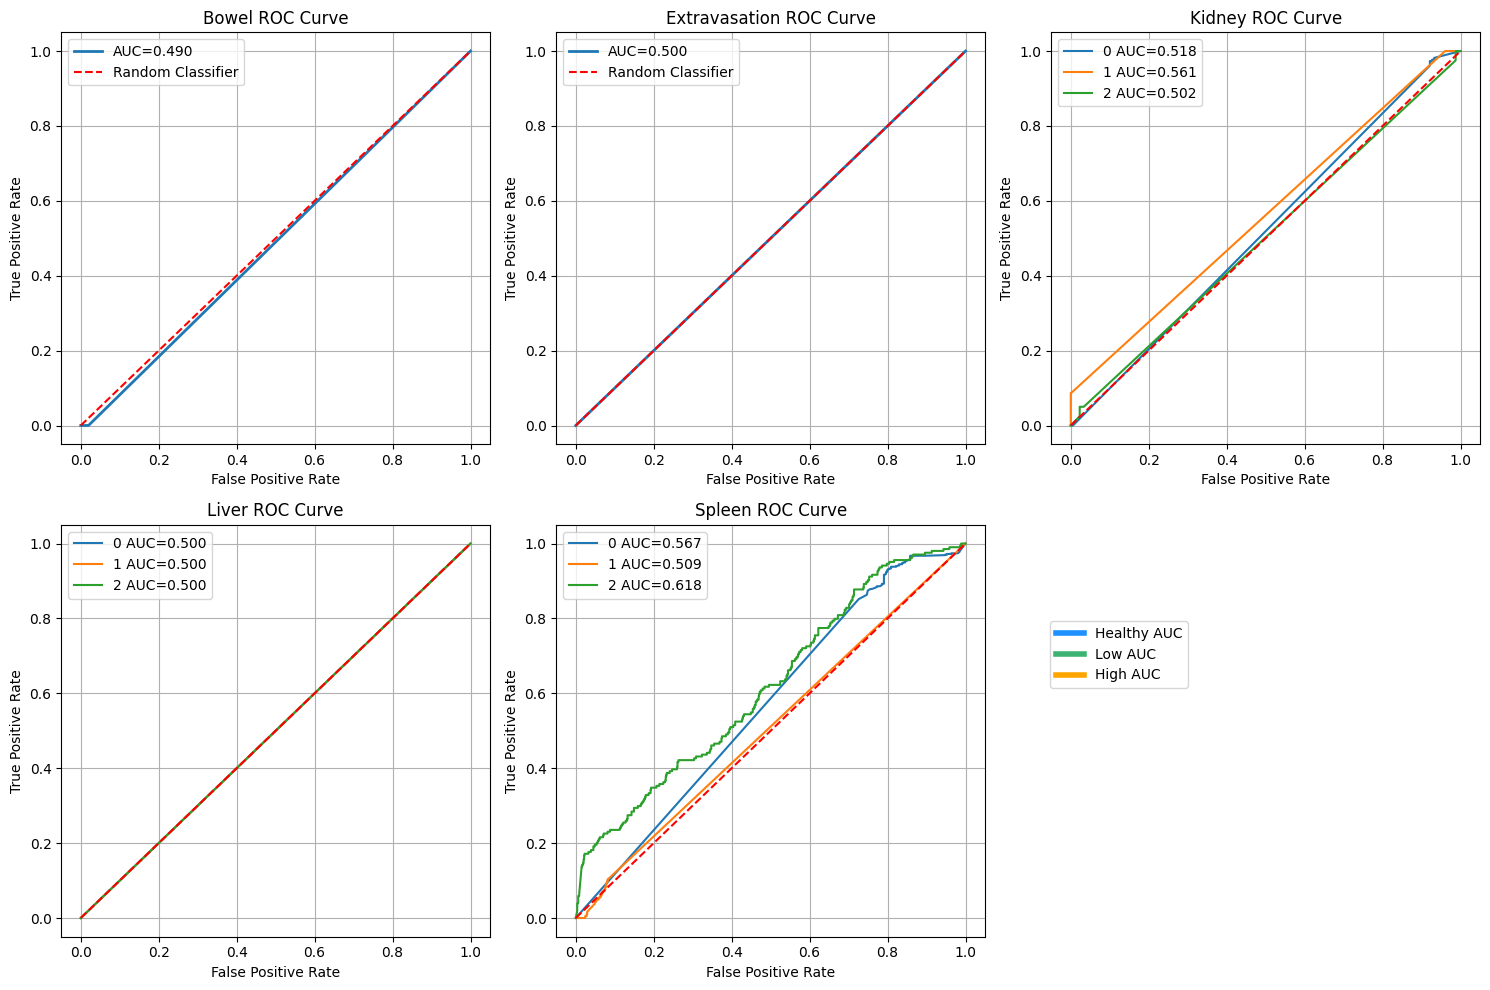

In [118]:
plot_roc_curves(ATD_Simple_Model,
                dataloader=test_simple_dataloader)

## 4.2 ATD_EfficientNetB1_Model.

In [119]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from efficientnet_pytorch import EfficientNet

class ATD_EfficientNet(nn.Module):
    def __init__(self, input_shape=3, model_name='efficientnet-b1', num_blocks_to_unfreeze=0):
        super().__init__()
        self.effincentnet_base = EfficientNet.from_pretrained(model_name, in_channels=input_shape, image_size=[IMAGE_SIZE,IMAGE_SIZE]) # Assuming pretrained with ImageNet weights

        # Freeze all parameters of EfficientNet if pretrained is True
        for param in self.effincentnet_base.parameters():
            param.requires_grad = False

        # Unfreeze specific blocks of EfficientNet for fine-tuning
        if num_blocks_to_unfreeze > 0:
            for param in self.effincentnet_base._blocks[-num_blocks_to_unfreeze:].parameters():
                param.requires_grad = True

        num_features = self.effincentnet_base._fc.in_features  # Get the number of features from the last layer of EfficientNet
        self.flatten = nn.Flatten()  # Flatten the output of EfficientNet
        self.global_pooling = nn.AdaptiveAvgPool2d(1)  # Global average pooling

        self.bowel_head = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.SiLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

        self.extra_head = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.SiLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

        self.liver_head = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.SiLU(),
            nn.Linear(64, 3),
            nn.Softmax()
        )

        self.kidney_head = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.SiLU(),
            nn.Linear(64, 3),
            nn.Softmax()
        )

        self.spleen_head = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.SiLU(),
            nn.Linear(64, 3),
            nn.Softmax()
        )

    def forward(self, x):
        x = self.flatten(self.global_pooling(self.effincentnet_base.extract_features(x)))
        bowel_out = self.bowel_head(x)
        extra_out = self.extra_head(x)
        kidney_out = self.kidney_head(x)
        liver_out = self.liver_head(x)
        spleen_out = self.spleen_head(x)
        return bowel_out, extra_out, kidney_out, liver_out, spleen_out

In [120]:
ATD_EfficientNetB1_Model_url = 'https://drive.google.com/uc?id=10QZZNdJL3H7EwcWJ5OR_yGG_JfBVqNhg'
gdown.download(ATD_EfficientNetB1_Model_url , quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=10QZZNdJL3H7EwcWJ5OR_yGG_JfBVqNhg
From (redirected): https://drive.google.com/uc?id=10QZZNdJL3H7EwcWJ5OR_yGG_JfBVqNhg&confirm=t&uuid=4939a9e5-ab09-461d-a729-272c216f3db5
To: /content/ATD_EfficientNetB1_Model.pth
100%|██████████| 32.9M/32.9M [00:00<00:00, 39.3MB/s]


'ATD_EfficientNetB1_Model.pth'

In [121]:
model_path='/content/ATD_EfficientNetB1_Model.pth'
ATD_EfficientNetB1_Model = ATD_EfficientNet(input_shape=3, model_name='efficientnet-b1', num_blocks_to_unfreeze=4).to(device)
ATD_EfficientNetB1_Model.load_state_dict(torch.load(model_path))

Loaded pretrained weights for efficientnet-b1


<All keys matched successfully>

In [122]:
model_evaluation(ATD_EfficientNetB1_Model,
                 dataloader=test_dataloader,
                 criterion_bowel=criterion_bowel,
                 criterion_extra=criterion_extra,
                 criterion_kidney=criterion_kidney,
                 criterion_liver=criterion_liver,
                 criterion_spleen=criterion_spleen)

Testing:   0%|          | 0/32 [00:00<?, ?it/s]

Test loss is: 4.0336
╒═══════════════════╤══════════╤═══════════════╤══════════╤══════════╤══════════╕
│ Results           │    bowel │   extravation │   kidney │    liver │   spleen │
╞═══════════════════╪══════════╪═══════════════╪══════════╪══════════╪══════════╡
│ Accuracy          │ 0.696723 │      0.306641 │ 0.535451 │ 0.439448 │ 0.512972 │
├───────────────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ F1_Score          │ 0.105202 │      0.349108 │ 0.512392 │ 0.36901  │ 0.415715 │
├───────────────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ Calibration_Error │ 0.136645 │      0.269455 │ 0.22173  │ 0.357833 │ 0.378537 │
╘═══════════════════╧══════════╧═══════════════╧══════════╧══════════╧══════════╛ 



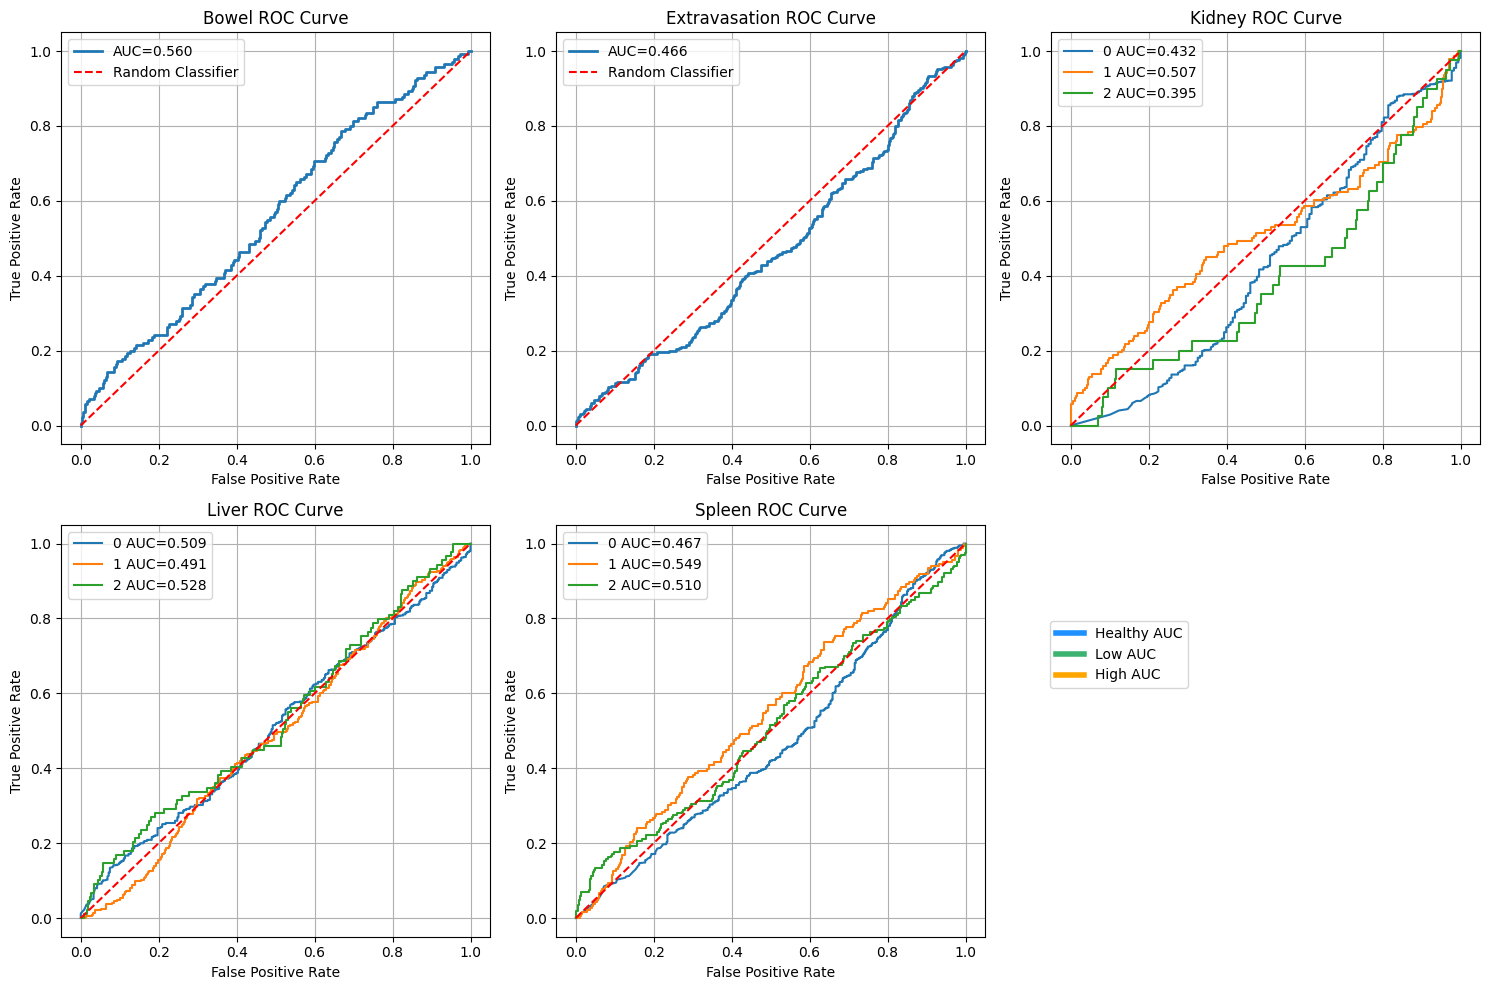

In [123]:
plot_roc_curves(ATD_EfficientNetB1_Model,
                dataloader=test_dataloader)

## 4.3 ATD_EfficientNetB1_CutMixUp_Model.

In [124]:
ATD_EfficientNetB1_CutMixUp_Model_url = 'https://drive.google.com/uc?id=11CgcxB_VctvytHMiFNrQzSryiRRFtJD3'
gdown.download(ATD_EfficientNetB1_CutMixUp_Model_url , quiet=False)

Downloading...
From: https://drive.google.com/uc?id=11CgcxB_VctvytHMiFNrQzSryiRRFtJD3
To: /content/ATD_EfficientNetB1_CutMixUp_Model.onnx
100%|██████████| 27.4M/27.4M [00:00<00:00, 142MB/s]


'ATD_EfficientNetB1_CutMixUp_Model.onnx'

In [125]:
!pip install onnx2torch

In [126]:
import onnx
import torch
from onnx2torch import convert

# Path to ONNX model
onnx_model_path = "/content/ATD_EfficientNetB1_CutMixUp_Model.onnx"
ATD_EfficientNetB1_CutMixUp_Model  = convert(onnx_model_path).to(device)

In [127]:
model_evaluation(ATD_EfficientNetB1_CutMixUp_Model,
                 dataloader=test_dataloader,
                 criterion_bowel=criterion_bowel,
                 criterion_extra=criterion_extra,
                 criterion_kidney=criterion_kidney,
                 criterion_liver=criterion_liver,
                 criterion_spleen=criterion_spleen)

Testing:   0%|          | 0/32 [00:00<?, ?it/s]

Test loss is: 6.9477
╒═══════════════════╤══════════╤═══════════════╤══════════╤══════════╤══════════╕
│ Results           │    bowel │   extravation │   kidney │    liver │   spleen │
╞═══════════════════╪══════════╪═══════════════╪══════════╪══════════╪══════════╡
│ Accuracy          │ 0.860352 │     0.724609  │ 0.496005 │ 0.469428 │ 0.475408 │
├───────────────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ F1_Score          │ 0        │     0.0547619 │ 0.478253 │ 0.400196 │ 0.380816 │
├───────────────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ Calibration_Error │ 0.151332 │     0.279807  │ 0.21568  │ 0.30352  │ 0.364984 │
╘═══════════════════╧══════════╧═══════════════╧══════════╧══════════╧══════════╛ 



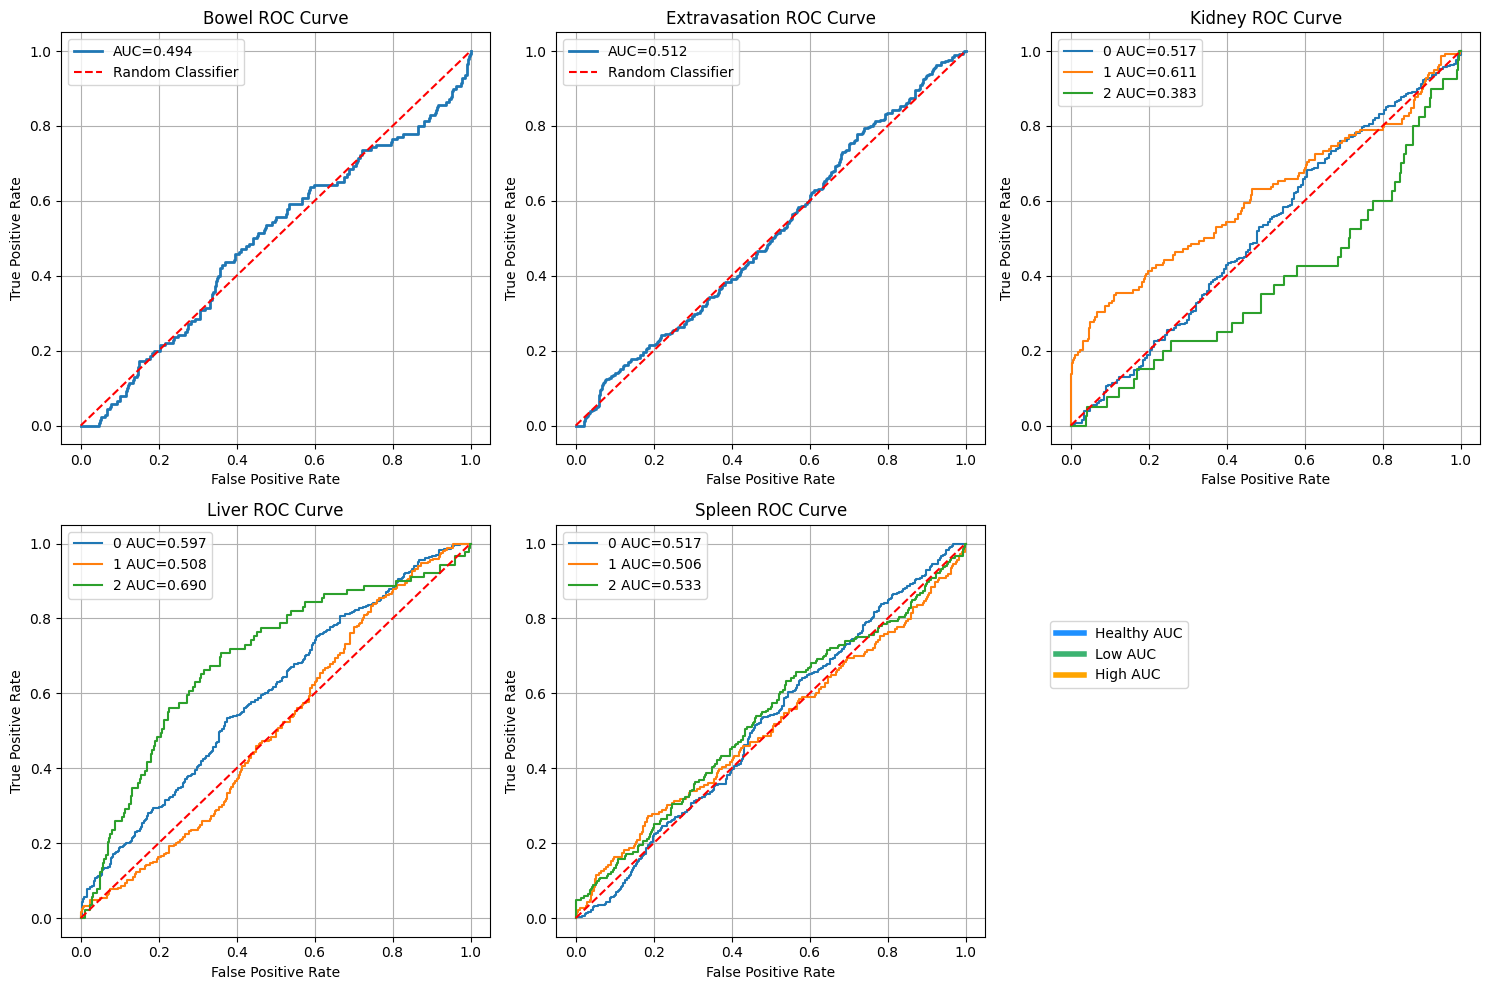

In [128]:
plot_roc_curves(ATD_EfficientNetB1_CutMixUp_Model,
                dataloader=test_dataloader)

## 4.4 ATD_ResNet50_Model

In [129]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class ATD_ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet_base = models.resnet50(pretrained=True)
        # Freeze all parameters of ResNet if pretrained is True
        for param in self.resnet_base.parameters():
            param.requires_grad = False

        # Unfreeze specific layers of ResNet for fine-tuning
        for param in self.resnet_base.layer3[-1:].parameters():
          param.requires_grad = True
        # Unfreeze specific layers of ResNet for fine-tuning
        for param in self.resnet_base.layer4[-3:].parameters():
          param.requires_grad = True

        num_features = self.resnet_base.fc.in_features  # Get the number of features from the last layer of ResNet
        self.resnet_base.fc = nn.Identity()  # Remove the original fully connected layer

        self.flatten = nn.Flatten()  # Flatten the output of ResNet
        self.dropout = nn.Dropout(0.3)  # Dropout with a dropout rate of 0.3

        self.bowel_head = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

        self.extra_head = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

        self.liver_head = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.SiLU(),
            nn.Linear(64, 3)
        )

        self.kidney_head = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.SiLU(),
            nn.Linear(64, 3)
        )

        self.spleen_head = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.SiLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        x = self.resnet_base(x)
        x = self.dropout(self.flatten(x))
        bowel_out = self.bowel_head(x)
        extra_out = self.extra_head(x)
        kidney_out = self.kidney_head(x)
        liver_out = self.liver_head(x)
        spleen_out = self.spleen_head(x)
        return bowel_out, extra_out, kidney_out, liver_out, spleen_out

In [130]:
ATD_ResNet50_Model_url = 'https://drive.google.com/uc?id=1-NGNtFIfvF7lRIDSXD5jcrk7KAEsnAt7'
gdown.download(ATD_ResNet50_Model_url , quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1-NGNtFIfvF7lRIDSXD5jcrk7KAEsnAt7
From (redirected): https://drive.google.com/uc?id=1-NGNtFIfvF7lRIDSXD5jcrk7KAEsnAt7&confirm=t&uuid=5cd0559f-60cf-47ba-8077-eace0e6d01f5
To: /content/ATD_ResNet50_Model.pth
100%|██████████| 96.5M/96.5M [00:01<00:00, 95.6MB/s]


'ATD_ResNet50_Model.pth'

In [131]:
model_path='/content/ATD_ResNet50_Model.pth'
ATD_ResNet50_Model = ATD_ResNet().to(device)
ATD_ResNet50_Model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [132]:
model_evaluation(ATD_ResNet50_Model,
                       dataloader=test_dataloader,
                       criterion_bowel=criterion_bowel,
                       criterion_extra=criterion_extra,
                       criterion_kidney=criterion_kidney,
                       criterion_liver=criterion_liver,
                       criterion_spleen=criterion_spleen)

Testing:   0%|          | 0/32 [00:00<?, ?it/s]

Test loss is: 15.0726
╒═══════════════════╤══════════╤═══════════════╤══════════╤══════════╤══════════╕
│ Results           │    bowel │   extravation │   kidney │    liver │   spleen │
╞═══════════════════╪══════════╪═══════════════╪══════════╪══════════╪══════════╡
│ Accuracy          │ 0.863281 │     0.722656  │ 0.678546 │ 0.514263 │ 0.55667  │
├───────────────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ F1_Score          │ 0        │     0.0381853 │ 0.626232 │ 0.431205 │ 0.43993  │
├───────────────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ Calibration_Error │ 0.136719 │     0.283712  │ 0.182935 │ 0.356542 │ 0.378655 │
╘═══════════════════╧══════════╧═══════════════╧══════════╧══════════╧══════════╛ 



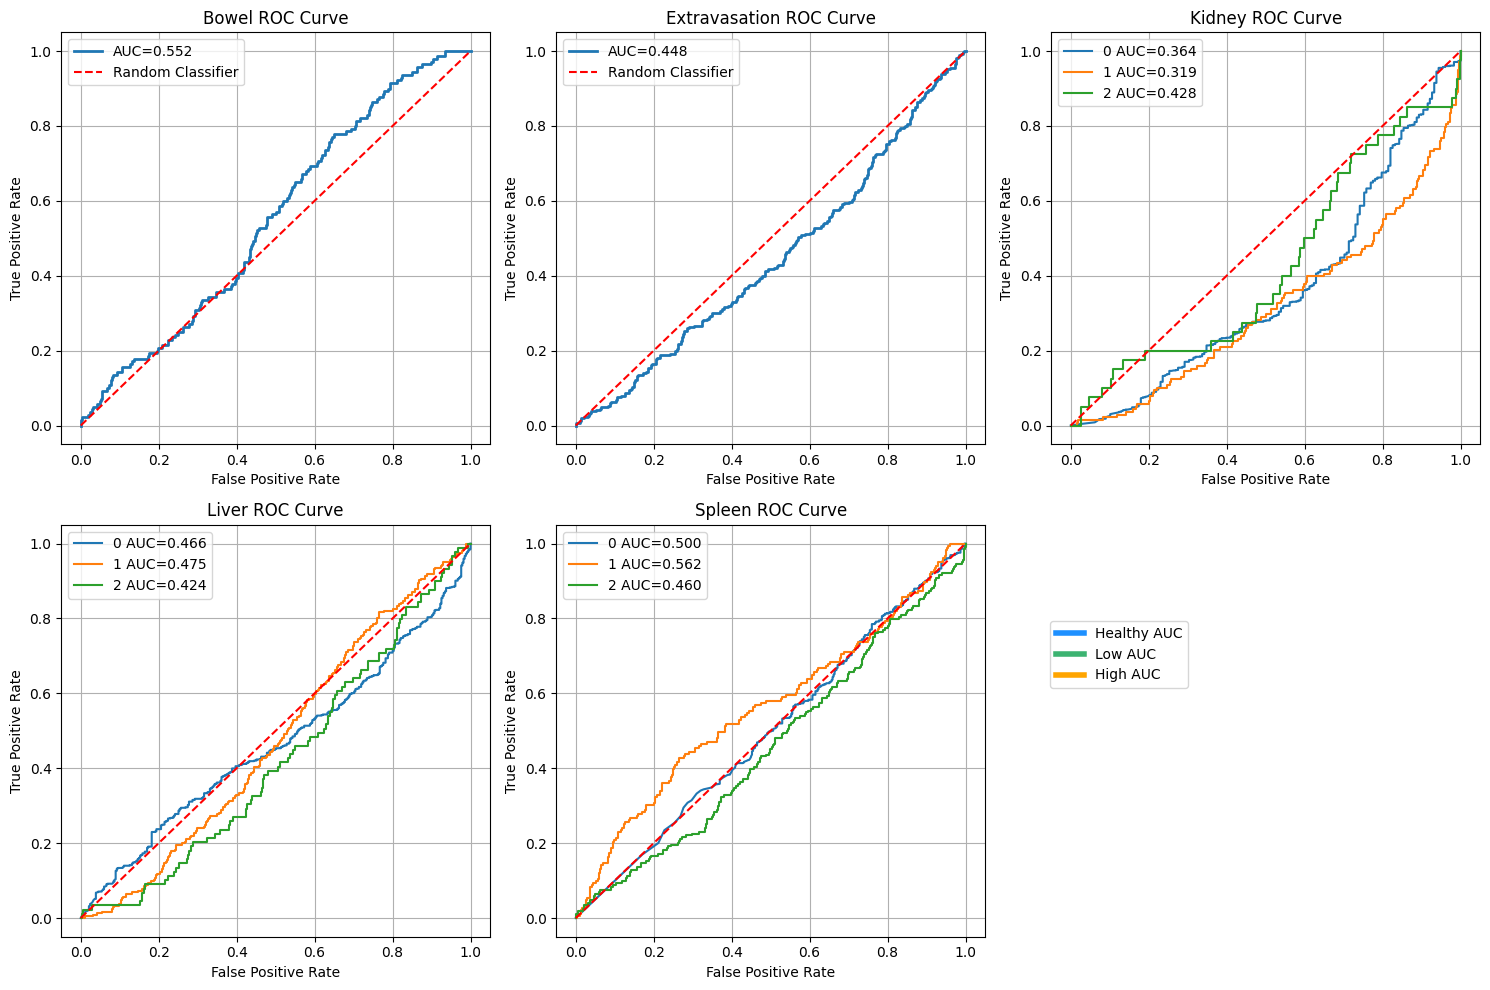

In [133]:
plot_roc_curves(ATD_ResNet50_Model,
                dataloader=test_dataloader)

## 4.5 ATD_ResNet50_CutMixUp_Model

In [134]:
ATD_ResNet50_CutMixUp_Model_url = 'https://drive.google.com/uc?id=1-lciP2eQnw07pS4POmepsjYRRV46mISU'
gdown.download(ATD_ResNet50_CutMixUp_Model_url , quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1-lciP2eQnw07pS4POmepsjYRRV46mISU
From (redirected): https://drive.google.com/uc?id=1-lciP2eQnw07pS4POmepsjYRRV46mISU&confirm=t&uuid=5627f1e2-0768-46e9-8c9c-100bf72d205d
To: /content/ATD_ResNet50_CutMixUp_Model.pth
100%|██████████| 96.5M/96.5M [00:01<00:00, 62.9MB/s]


'ATD_ResNet50_CutMixUp_Model.pth'

In [135]:
model_path='/content/ATD_ResNet50_CutMixUp_Model.pth'
ATD_ResNet50_CutMixUp_Model = ATD_ResNet().to(device)
ATD_ResNet50_CutMixUp_Model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [136]:
model_evaluation(ATD_ResNet50_CutMixUp_Model,
                 dataloader=test_dataloader,
                 criterion_bowel=criterion_bowel,
                 criterion_extra=criterion_extra,
                 criterion_kidney=criterion_kidney,
                 criterion_liver=criterion_liver,
                 criterion_spleen=criterion_spleen)

Testing:   0%|          | 0/32 [00:00<?, ?it/s]

Test loss is: 8.1530
╒═══════════════════╤══════════╤═══════════════╤══════════╤══════════╤══════════╕
│ Results           │    bowel │   extravation │   kidney │    liver │   spleen │
╞═══════════════════╪══════════╪═══════════════╪══════════╪══════════╪══════════╡
│ Accuracy          │ 0.863281 │      0.740234 │ 0.712077 │ 0.59692  │ 0.449056 │
├───────────────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ F1_Score          │ 0        │      0        │ 0.658628 │ 0.496773 │ 0.376052 │
├───────────────────┼──────────┼───────────────┼──────────┼──────────┼──────────┤
│ Calibration_Error │ 0.138975 │      0.259735 │ 0.175415 │ 0.32285  │ 0.383006 │
╘═══════════════════╧══════════╧═══════════════╧══════════╧══════════╧══════════╛ 



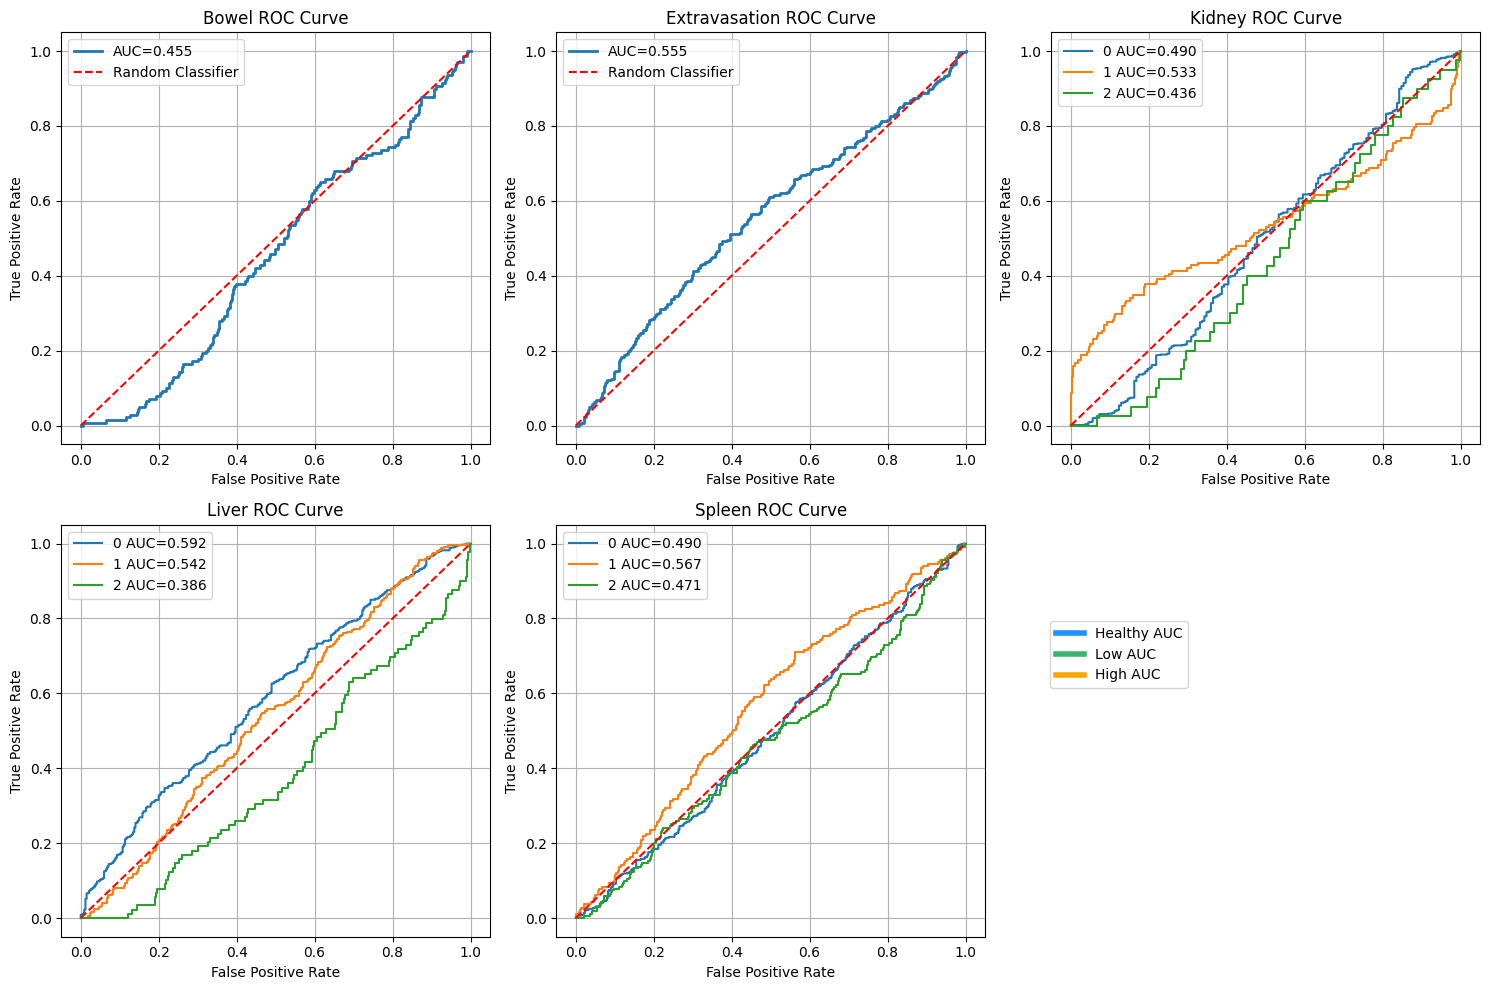

In [137]:
plot_roc_curves(ATD_ResNet50_CutMixUp_Model,
                dataloader=test_dataloader)